# Семинар 4. Выбор модели. Валидация. Настройка гиперпараметров.

Уже научились читать и чистить данные. Познакомились с некоторыми моделями машинного обучения, а также понятием метрики.

**Но как понять, что мы не переобучились? Достаточной ли обобщающей способностью обладает модель? На сколько хорош выбранный _пайплайн_ в целом?**

<div style="text-align:center">
<img src="src/overfitting.png" width="650px">
</div>

Проблема выбора:
- модели алгоритмов
- гиперпараметров
- способа предобработки данных


**Валидация** - процедура эмпирического оценивания обобщающей способности модели, которая используется для сравнения между собой различных моделей и выбора наилучшей для конкретной задачи.

---------------------------

## [Разбиение данных](https://education.yandex.ru/handbook/ml/article/kross-validaciya)


### Общая схема разбиения данных: Train / Validation / Test Set

- **Обучающая выборка** - Training set (70%)
  - обучение модели (настойка ее параметров / весов)
- **Валидационная выборка** - Validation set (15%)
  - выбор пайплайна (модели / гиперпараметров / способа обработки данных)
  - иногда: локальный контроль
- **Тестовая выборка** - Test set (15%)
  - оценка качества алгоритма
  - иногда: итоговая оценка алгоритма
  - _лучше выбрать в самом начале и вспомнить только на финальном этапе_

<div style="text-align:center">
<img src="src/data_split.png" width="650px">
</div>

**Оптимизация качества моделей и их сравнение на одном и том же множестве, может неявно заложить в модели информацию о тестовом множестве, что может привести к получению результатов хуже ожидаемых на новых данных.**

Реализация разбиения в [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

```

sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)

```
- ``train_size/test_size: Optional[Union[int, float]]`` - $100: 70/30 \rightarrow 30: 50/50$ - для начального приближения; здравый смысл далее;
  - большее обучение:
    - более репрезентативная обучающая выборка
  - больший контроль:
    - более надежная оценка качества
- ``random_state`` - воспроизводимость результатов
- ``shuffle: bool`` - перемешивание сэмплов.
  - Важно смотреть на природу данных!
- ``stratify`` - _(стратификация)_ разбиение на трейн и тест, сохраняющее соотношение классов, представленное в исходном датасете.
  - Важно с случае сильно несбалансированных данных!

<div style="text-align:center">
<img src="src/general-population.svg" width="650px">
</div>

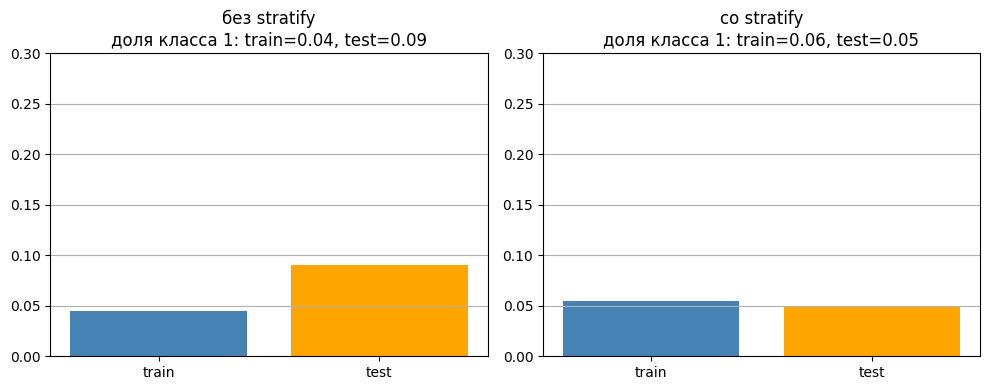

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np

X, y = make_classification(
    n_samples=500, n_classes=2, weights=[0.95, 0.05]
)

# без стратификации
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=None
)

# со стратификацией
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.2, stratify=y
)

fig, axs = plt.subplots(ncols=2, figsize=(10, 4))

for ax, (yr, yt), title in zip(
    axs,
    [(y_train, y_test), (y_train_s, y_test_s)],
    ["без stratify", "со stratify"],
):
    train_ratio = np.mean(yr)
    test_ratio = np.mean(yt)
    ax.bar(["train", "test"], [train_ratio, test_ratio], color=["steelblue", "orange"])
    ax.set_ylim(0, 0.3)
    ax.set_title(f"{title}\nдоля класса 1: train={train_ratio:.2f}, test={test_ratio:.2f}")
    ax.grid(axis="y")

plt.tight_layout()

Для обучения и выбора модели есть много вариантов разбиения:

------------------

### [Кросс-Валидация](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html)

Зачастую, когда говорят о кросс-валидации имеют в виду именно  метод [K-Fold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html).

Он устроен следующим образом:

- Фиксируем целое число K (обычно от 5 до 10 и нечетное)
- Делим выборку на K примерно равных частей (фолдов)
- Цикл по i = 1...K:
  - Использовать i-ую часть для валидации, объединение остальных - для обучения.
- Финальный скор модели получается либо усреднением K получившихся тестовых результатов, либо измеряется на отложенном тестовом множестве, не участвовавшем в кросс-валидации.

<div style="text-align:center">
<img src="src/CV.png" width="650px">
</div>

В scikit-learn реализовано несколько дополнительных методов:
  - [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) - в отличие от K-Fold принимает на вход не только данные, но и модель, и прочие параметры.
    - на выходе оценивает ее качество, а не возвращает разбиение данных.
  - [StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html) - это метод K-Fold, использующий стратификацию при разбиении на фолды: каждый фолд содержит примерно такое же соотношение классов, как и всё исходное множество.
    - Такой подход может потребоваться в случае, например, очень несбалансированного соотношения классов, когда при обычном random split некоторые фолды могут либо вообще не содержать семплов каких-то классов, либо содержать их слишком мало.

MAE по фолдам: [8.97408914 9.88126907 7.64774845 8.54834918 6.63733762]
среднее MAE: 8.34 ± 1.11


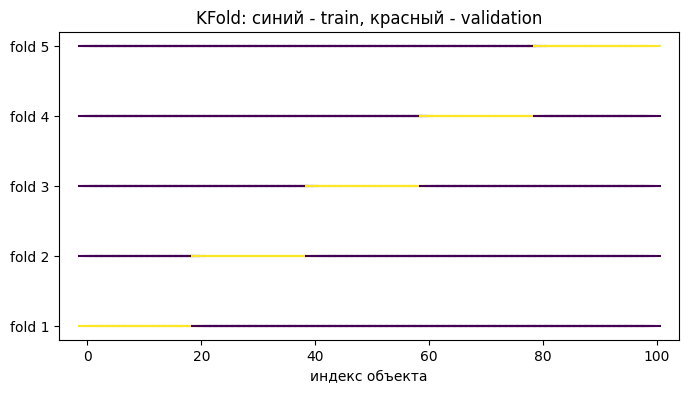

In [3]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

X, y = make_regression(n_samples=100, n_features=5, noise=10, random_state=42)

kf = KFold(n_splits=5, shuffle=False)
#kf = KFold(n_splits=5, shuffle=True)

fig, ax = plt.subplots(figsize=(8, 4))
for i, (train_idx, val_idx) in enumerate(kf.split(X)):
    mask = np.zeros(len(X))
    mask[val_idx] = 1
    ax.scatter(range(len(X)), [i] * len(X), c=mask, marker="_", s=200)

ax.set_yticks(range(5))
ax.set_yticklabels([f"fold {i+1}" for i in range(5)])
ax.set_xlabel("индекс объекта")
ax.set_title("KFold: синий - train, красный - validation")

model = Ridge()
scores = cross_val_score(model, X, y, cv=kf, scoring="neg_mean_absolute_error")
print(f"MAE по фолдам: {-scores}")
print(f"среднее MAE: {-scores.mean():.2f} ± {scores.std():.2f}")

#### StratifiedKFold в действии: несбалансированные классы

Обычный `KFold` режет данные, не глядя на метки. При редком классе часть фолдов получает слишком мало (а то и ноль) объектов миноритарного класса — метрика на таком фолде шумная или вообще не определена. `StratifiedKFold` сохраняет долю классов в каждом фолде.

#### `cross_validate` — больше информации, чем `cross_val_score`

`cross_val_score` возвращает одну метрику на фолд. `cross_validate` умеет:
- считать **несколько метрик** за один проход (`scoring` — словарь);
- возвращать **качество на обучении** (`return_train_score=True`) — сразу видно разрыв train/validation, то есть переобучение;
- измерять `fit_time` и `score_time` — полезно при выборе между моделями.

In [5]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

X_imb, y_imb = make_classification(
    n_samples=200, n_features=10, n_informative=5,
    weights=[0.95, 0.05], flip_y=0, class_sep=1.5, random_state=0
)

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
res = cross_validate(
    RandomForestClassifier(n_estimators=100, random_state=0),
    X_imb, y_imb, cv=cv_strat,
    scoring={"f1": "f1", "recall": "recall", "roc_auc": "roc_auc"},
    return_train_score=True, n_jobs=-1,
)

print(f"{'метрика':<10}{'train':>18}{'validation':>18}")
for m in ["f1", "recall", "roc_auc"]:
    tr, va = res[f"train_{m}"], res[f"test_{m}"]
    print(f"{m:<10}{tr.mean():>11.3f} ± {tr.std():.3f}{va.mean():>11.3f} ± {va.std():.3f}")
print(f"\nfit_time: {res['fit_time'].mean():.2f} c на фолд, score_time: {res['score_time'].mean():.3f} c")

метрика                train        validation
f1              1.000 ± 0.000      0.733 ± 0.133
recall          1.000 ± 0.000      0.600 ± 0.200
roc_auc         1.000 ± 0.000      0.964 ± 0.046

fit_time: 0.12 c на фолд, score_time: 0.019 c


### [Leave-One-Out / LOO](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeaveOneOut.html)

- Вырождение K-Fold при K соответсвующем размеру выборки (каждый фолд состоит ровно из одного сэмлпа).

<div style="text-align:center">
<img src="src/LOOCV.png" width="650px">
</div>

- Большие k:
  + (+) надёжнее оценка качества
  + (+) обучающая выборка больше походит на все данные
  - (-) вычислительно затратно
    - обычно применяют
      -  когда данных достаточно мало
      -  при наличии большого количества вычислительных ресурсов, позволяющих проводить все K итераций параллельно.
  - (-) не любое качество адекватно оценивается на маленьких подвыборках

### [Бутстреп (Bootstrap)](https://v-marco.github.io/psmo_book/content/bootstrap/seminar.html)

-  это псевдовыборка с возвращением, формируется как подвыборка полного объёма, на которой производится обучение модели, а на остальных объектах (которые не попали в обучение) – контроль.

<div style="text-align:center">
<img src="src/bootstrap.png" width="650px">
</div>


В контроль попадает:

$$ \left ( 1 - \frac{1}{m} \right )^m \approx e^{-1} \approx 0.37$$

- Модель учится на выборке того же объема, что и итоговая
- Похожа на исходную с точки зрения распределенения
- Имеются дубликаты

#### Bootstrap в коде: OOB-оценка и доверительный интервал

Реализуем схему из описания вручную: на каждой итерации берём выборку с возвращением того же объёма, учим модель на ней, а контролируем на объектах, **не попавших** в выборку (out-of-bag, OOB). Заодно проверим, что в контроль действительно попадает ≈ 37% объектов, и получим не просто число, а **распределение** ошибки — это главное преимущество бутстрепа перед одиночным разбиением.

Средняя доля OOB-объектов: 0.366  (теория: e^-1 ≈ 0.368)


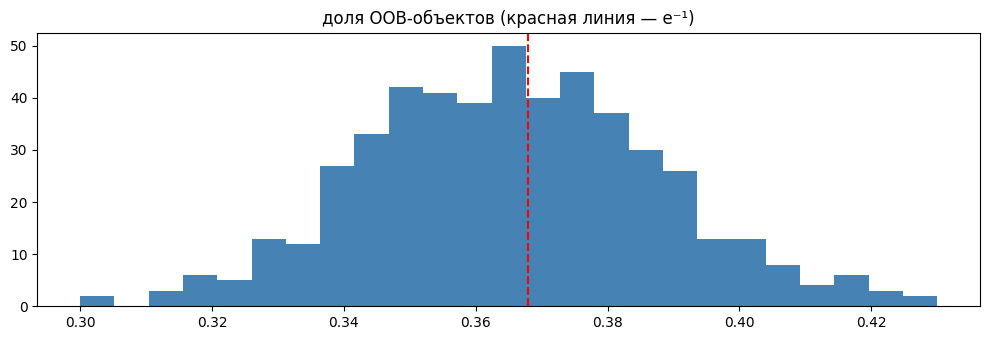

In [6]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import make_regression

X_b, y_b = make_regression(n_samples=200, n_features=5, noise=15, random_state=0)
n = len(X_b)
rng = np.random.default_rng(0)

oob_share, oob_mae = [], []
for _ in range(500):
    train_idx = rng.integers(0, n, size=n)              # выборка с возвращением, объём = n
    oob_idx = np.setdiff1d(np.arange(n), train_idx)     # не попавшие в обучение
    model = Ridge().fit(X_b[train_idx], y_b[train_idx])
    oob_share.append(len(oob_idx) / n)
    oob_mae.append(mean_absolute_error(y_b[oob_idx], model.predict(X_b[oob_idx])))

print(f"Средняя доля OOB-объектов: {np.mean(oob_share):.3f}  (теория: e^-1 ≈ {np.exp(-1):.3f})")

fig, axs = plt.subplots(ncols=1, figsize=(10, 3.5))
axs.hist(oob_share, bins=25, color="steelblue"); axs.axvline(np.exp(-1), color="red", ls="--")
axs.set_title("доля OOB-объектов (красная линия — e⁻¹)")
plt.tight_layout()

### Контроль по времени. [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)

Контроль качества в задаче прогнозирования временных рядов имеет существенную особенность - данные не должны пересекаться по времени: тренировочные данные должны идти до валидационных, а валидационные — до тестовых. С учётом этих особенностей фолды в кросс-валидации для временных рядов располагаются вдоль временной оси так, как показано на следующей картинке:

<div style="text-align:center">
<img src="src/time_series.png" width="650px">
</div>

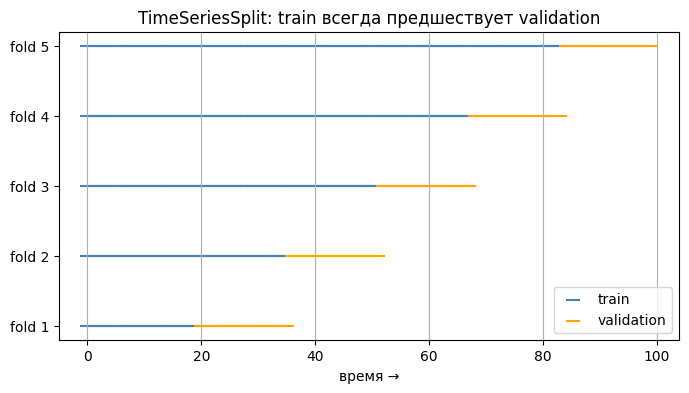

In [7]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import matplotlib.pyplot as plt

n_samples = 100
tscv = TimeSeriesSplit(n_splits=5)

fig, ax = plt.subplots(figsize=(8, 4))
for i, (train_idx, val_idx) in enumerate(tscv.split(np.arange(n_samples))):
    ax.scatter(train_idx, [i] * len(train_idx), c="steelblue", marker="_", s=100, label="train" if i == 0 else None)
    ax.scatter(val_idx, [i] * len(val_idx), c="orange", marker="_", s=100, label="validation" if i == 0 else None)

ax.set_yticks(range(5))
ax.set_yticklabels([f"fold {i+1}" for i in range(5)])
ax.set_xlabel("время →")
ax.set_title("TimeSeriesSplit: train всегда предшествует validation")
ax.legend()
ax.grid(axis="x")

## Утечка данных (data leakage) и `Pipeline`

Самая частая ошибка при валидации — **использовать информацию из валидационных данных на этапе подготовки**: масштабировать признаки, кодировать категории, заполнять пропуски или отбирать признаки по *всей* выборке, а потом делить на фолды. Фолд «подсмотрел» в свои же данные, оценка становится завышенной.

Классическая демонстрация: **случайные** признаки и **случайные** метки. Честное качество — 50%. Посмотрим, что покажет валидация, если отбор признаков сделать до кросс-валидации.

In [10]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(0)
X_noise = rng.normal(size=(100, 5000))     # 5000 признаков-шума
y_noise = rng.integers(0, 2, size=100)     # случайные метки: предсказывать нечего

# ❌ Неправильно: отбираем 20 "лучших" признаков по ВСЕЙ выборке, потом CV
X_sel = SelectKBest(f_classif, k=20).fit_transform(X_noise, y_noise)
wrong = cross_val_score(LogisticRegression(max_iter=1000), X_sel, y_noise, cv=5).mean()

# ✅ Правильно: отбор признаков внутри Pipeline — на каждом фолде только по его train-части
pipe = make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=1000))
right = cross_val_score(pipe, X_noise, y_noise, cv=5).mean()

print(f"Accuracy с утечкой (отбор до CV):    {wrong:.2f}   <- 'модель' угадывает шум!")
print(f"Accuracy без утечки (Pipeline в CV): {right:.2f}   <- честные ~0.5")

Accuracy с утечкой (отбор до CV):    0.85   <- 'модель' угадывает шум!
Accuracy без утечки (Pipeline в CV): 0.48   <- честные ~0.5


`Pipeline` решает проблему целиком: на каждом фолде все шаги (`fit`) выполняются **только на train-части фолда**, а на валидационную часть применяется лишь `transform`. Это относится к любому препроцессингу — `StandardScaler`, `OneHotEncoder`, `SimpleImputer`, PCA и т.д. (для смешанных типов признаков — `ColumnTransformer` внутри `Pipeline`).

## Диагностика: `validation_curve` и `learning_curve`

В начале семинара была картинка про недо- и переобучение. Вот как это **измерить**:

- **`validation_curve`** — качество на train и validation в зависимости от одного гиперпараметра (сложности модели). Слева от оптимума — недообучение (обе кривые низкие), справа — переобучение (train растёт, validation падает).
- **`learning_curve`** — качество в зависимости от **размера обучающей выборки**. Помогает ответить на вопрос «нужно ли больше данных?»:
  - обе кривые низкие и сошлись → **высокое смещение** (high bias), модель слишком проста, больше данных не поможет;
  - большой зазор между train и validation → **высокая дисперсия** (high variance), больше данных или регуляризация помогут.

<div style="text-align:center">
<img src="src/bias-var.png" width="650px">
</div>

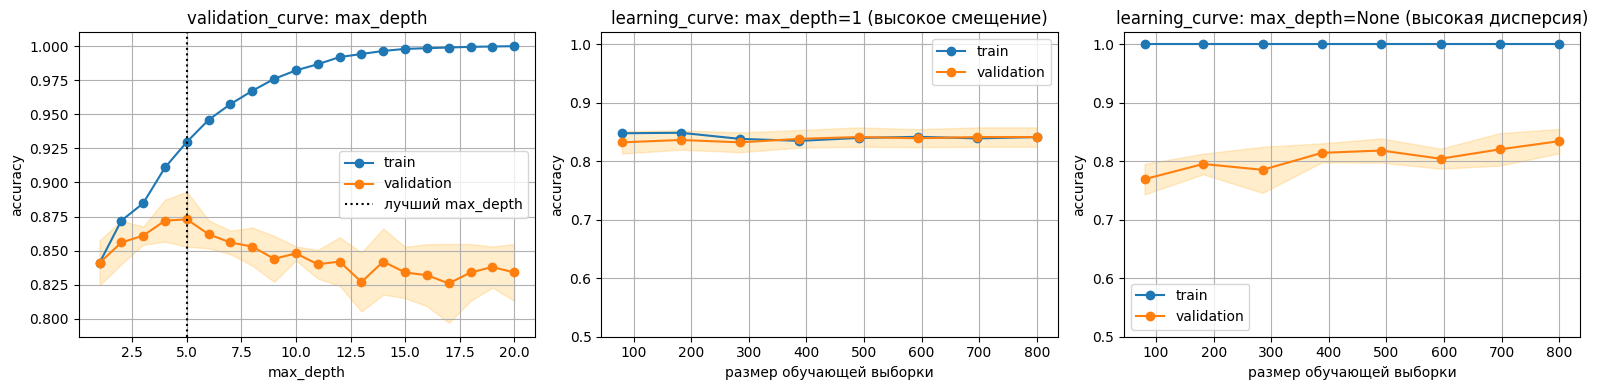

In [11]:
from sklearn.model_selection import validation_curve, learning_curve
from sklearn.tree import DecisionTreeClassifier

X_lc, y_lc = make_classification(n_samples=1000, n_features=20, n_informative=5, flip_y=0.1, random_state=0)

fig, axs = plt.subplots(ncols=3, figsize=(16, 4))

# 1) validation_curve по глубине дерева
depths = np.arange(1, 21)
tr, va = validation_curve(DecisionTreeClassifier(random_state=0), X_lc, y_lc,
                          param_name="max_depth", param_range=depths, cv=5)
axs[0].plot(depths, tr.mean(1), "o-", label="train")
axs[0].plot(depths, va.mean(1), "o-", label="validation")
axs[0].fill_between(depths, va.mean(1) - va.std(1), va.mean(1) + va.std(1), alpha=0.2, color="orange")
axs[0].axvline(depths[va.mean(1).argmax()], color="k", ls=":", label="лучший max_depth")
axs[0].set(title="validation_curve: max_depth", xlabel="max_depth", ylabel="accuracy"); axs[0].legend(); axs[0].grid()

# 2-3) learning_curve для простой и сложной модели
models = {
    "max_depth=1 (высокое смещение)": DecisionTreeClassifier(max_depth=1, random_state=0),
    "max_depth=None (высокая дисперсия)": DecisionTreeClassifier(random_state=0),
}
for ax, (name, est) in zip(axs[1:], models.items()):
    sizes, tr, va = learning_curve(est, X_lc, y_lc, cv=5, train_sizes=np.linspace(0.1, 1.0, 8),
                                   shuffle=True, random_state=0)
    ax.plot(sizes, tr.mean(1), "o-", label="train")
    ax.plot(sizes, va.mean(1), "o-", label="validation")
    ax.fill_between(sizes, va.mean(1) - va.std(1), va.mean(1) + va.std(1), alpha=0.2, color="orange")
    ax.set(title=f"learning_curve: {name}", xlabel="размер обучающей выборки", ylabel="accuracy", ylim=(0.5, 1.02))
    ax.legend(); ax.grid()
plt.tight_layout()

#### FYI: [Больше разбиений](https://scikit-learn.org/stable/api/sklearn.model_selection.html)


#### На что обратить внимание?

- высокое качество на обучении и низкое на контроле - overfitting
  - сложность модели, шум, нерепрезентативность
- низкое качество на обучении и контроле -  underfitting
- нужно ли перемешивать данные? перемешали ли вы их?
- не подглядываете в тест в процессе обработки/обучения/подбора гиперпараметров?
- временные ряды
- препроцессинг и отбор признаков делается **внутри** фолдов (`Pipeline`), а не до разбиения


------------------

## Гиперпараметры


Чем гиперпараметры отличаются от параметров модели?
  - Параметры модели настраиваются в процессе обучения модели на данных
  - Гиперпараметры - характеристики модели, которые фиксируются до начала обучения модели (экспертно или переборно)

Простейшие примеры гиперпараметров:
 - параметр регуляризации
 - темп обучения градиентного спуска (learning rate)

### Простейшие стратегии подбора гиперпараметров. Переборные методы.

#### Поиск по сетке. [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
Самым наивным способом поиска оптимального набора гиперпараметров является поиск по сетке. Метод выполняет полный перебор по изначально заданному подмножеству гиперпараметров выбранного алгоритма. Так как пространство поиска гиперпараметров выбранной модели машинного обучения может быть непрерывным и неограниченным, ML-разработчик сам должен установить границы и провести дискретизацию значений. Качество алгоритма поиска обычно определяется с помощью перекрестной проверки или отложенного набора данных. В результате своей работы алгоритм **поиска по сетке** выдаёт модель с гиперпараметрами, на которых был достигнут наилучший результат в процессе проверки.

Основным недостатком данного метода является *проклятие размерности* -- проблема экспоненциального роста необходимых экспериментальных данных в зависимости от роста размерности пространства. Однако обычно метод довольно легко поддается распараллеливанию, так как зачастую гиперпараметры не зависят друг от друга.  


#### Случайный поиск. [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)
Основной идей случайного поиска является независимое сэмлирование из заранее определенного подмножества гиперпараметров до тех пор, пока не будет исчерпан заранее определенный бюджет, например, максимальное количество итераций. В отличие от предыдущего метода от разработчика не требуется проводить дискретизацию непрерывных значений, нужно лишь ограничить пространство поиска. Так же, как и  *поиск по сетке*, *случайный поиск* поддерживает параллельную работу, так как вычисления могут выполняться независимо, а также позволяет использовать априорные знания об оптимизируемых параметрах путем указания распределения на них. *Случайный поиск* превосходит *поиск по сетке* в случае, если на качество модели оказывает влияние лишь малое количество параметров.

<div style="text-align:center">
<img src="src/grid_vs_random_search.png" width="650px">,
</div>

График функция $g(x)$ изображен зеленым цветом сверху квадрата, а график функции $h(y)$ представлен на левой боковой части квадрата. В случае использования поиска по сетке, из $9$ измерений только $3$  протестируют функцию $g(x)$ в разных точках. При использовании случайного поиска все $9$ измерений эффективно исследуют $g(x)$ в $9$ разных точках. Такое поведение метода *поиска по сетке* в сравнении с методом *случайного поиска* является скорее правилом, чем исключением, в многомерной гиперпараметрической оптимизации.

In [21]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from scipy.stats import randint
import time

X, y = make_regression(n_samples=300, n_features=10, noise=15, random_state=42)

param_grid = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [3, 5, 7, 10],
    "min_samples_leaf": [1, 2, 4, 8],
}

# GridSearchCV - перебирает ВСЕ комбинации: 4*4*4 = 64
start = time.time()
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=4), param_grid, cv=3, scoring="neg_mean_absolute_error", n_jobs=-1
)
grid_search.fit(X, y)
grid_time = time.time() - start

# RandomizedSearchCV - фиксированный бюджет итераций, например 15
param_dist = {
    "n_estimators": randint(50, 200),
    "max_depth": randint(3, 10),
    "min_samples_leaf": randint(1, 8),
}
start = time.time()
random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=4), param_dist, n_iter=15, cv=3,
    scoring="neg_mean_absolute_error", random_state=42, n_jobs=-1
)
random_search.fit(X, y)
random_time = time.time() - start

print(f"GridSearchCV:      {len(grid_search.cv_results_['params'])} комбинаций, "
      f"{grid_time:.1f} сек, лучший MAE: {-grid_search.best_score_:.2f}")
print(f"RandomizedSearchCV: {len(random_search.cv_results_['params'])} комбинаций, "
      f"{random_time:.1f} сек, лучший MAE: {-random_search.best_score_:.2f}")

GridSearchCV:      64 комбинаций, 4.0 сек, лучший MAE: 75.78
RandomizedSearchCV: 15 комбинаций, 0.9 сек, лучший MAE: 75.63


#### Successive Halving: «турнир» конфигураций

`HalvingGridSearchCV`, `HalvingRandomSearchCV`:

1. Берём **много** кандидатов и оцениваем каждого на **маленькой** части данных (дёшево).
2. Оставляем лучшую долю (`1/factor`), увеличиваем ресурс (по умолчанию — число объектов) в `factor` раз.
3. Повторяем, пока не останется победитель, обученный на полной выборке.

Плохие конфигурации отсеиваются рано и не тратят вычисления. Выигрыш заметен на больших выборках и дорогих моделях, поэтому возьмём данные побольше (ячейка считается заметно дольше предыдущих — на слабой машине уменьшите `n_samples`).

In [22]:
import time
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, HalvingRandomSearchCV

X_h, y_h = make_regression(n_samples=2000, n_features=20, n_informative=8, noise=20, random_state=0)
param_grid_h = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [3, 5, 7, 10],
    "min_samples_leaf": [1, 2, 4, 8],
}
base = RandomForestRegressor(random_state=0)
common = dict(cv=3, scoring="neg_mean_absolute_error", n_jobs=-1)

searches = {
    "GridSearchCV": GridSearchCV(base, param_grid_h, **common),
    "HalvingGridSearchCV": HalvingGridSearchCV(base, param_grid_h, factor=3, random_state=0, **common),
}
for name, s in searches.items():
    t = time.time(); s.fit(X_h, y_h); dt = time.time() - t
    print(f"{name:<22}{dt:6.1f} c | MAE: {-s.best_score_:.2f} | {s.best_params_}")

h = searches["HalvingGridSearchCV"]
print("\nКандидатов на каждой итерации:", h.n_candidates_)
print("Объектов в обучении на итерации:", h.n_resources_)

GridSearchCV            34.2 c | MAE: 54.56 | {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}
HalvingGridSearchCV     21.0 c | MAE: 54.69 | {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 200}

Кандидатов на каждой итерации: [64, 22, 8, 3]
Объектов в обучении на итерации: [74, 222, 666, 1998]


[**Примеры использования.**](https://scikit-learn.org/stable/modules/grid_search.html#randomized-parameter-optimization)

**Другие библиотеки**: [Optuna](https://optuna.org/), [scikit-optimize](https://scikit-optimize.github.io/stable/index.html), [hyperopt](http://hyperopt.github.io/hyperopt/).


### Вложенная кросс-валидация (Nested CV)


**Проблема.** `GridSearchCV.best_score_` — это *максимум* по многим кандидатам, каждый из которых оценён на одних и тех же фолдах. Чем больше кандидатов и чем меньше данных, тем вероятнее, что победитель просто «повезло» с разбиением. Значит, `best_score_` **завышает** ожидаемое качество на новых данных — те же данные и выбрали модель, и оценили её.

**Решение — два контура:**
- **внутренний** цикл (`GridSearchCV` со своим `cv`) — подбирает гиперпараметры;
- **внешний** цикл (`cross_val_score` со своим `cv`) — оценивает *всю процедуру* «подбор + обучение» на данных, которые внутренний цикл не видел.

<div style="text-align:center">
<img src="src/ncv.png" width="650px">
</div>

Завышение тем сильнее, чем **меньше данных**, **слабее сигнал** и **больше кандидатов** в сетке. На большой выборке с сильным сигналом разница почти исчезает, поэтому демонстрация ниже нарочно построена на маленькой и трудной задаче.

Стоимость: `K_outer × K_inner × |сетка|` обучений. Nested CV оценивает **процедуру**, а не конкретную модель: итоговую модель после этого обучают обычным `GridSearchCV.fit` на всей обучающей выборке. Альтернатива, если данных много, — честный отложенный test.

best_score_ (без вложенности): 0.643
Nested CV:                     0.602
Оптимизм оценки:               +0.042  (в 80% запусков best_score_ выше)


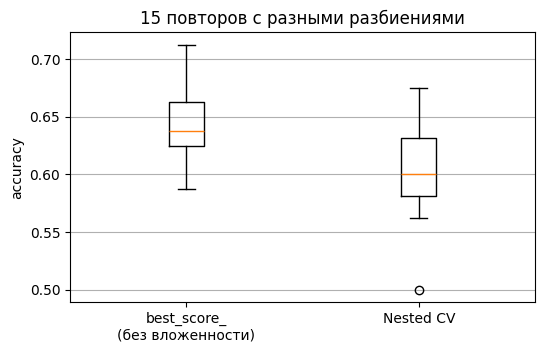

In [25]:
from sklearn.svm import SVC

X_n, y_n = make_classification(n_samples=80, n_features=30, n_informative=4, n_redundant=0,
                               class_sep=0.8, flip_y=0.1, random_state=0)   # мало данных и слабый сигнал
param_grid_n = {"C": np.logspace(-2, 3, 6), "gamma": np.logspace(-4, 0, 5)}

non_nested, nested = [], []
for seed in range(15):                          # повторяем с разными разбиениями
    inner = KFold(5, shuffle=True, random_state=seed)
    outer = KFold(5, shuffle=True, random_state=100 + seed)
    clf = GridSearchCV(SVC(), param_grid_n, cv=inner)
    clf.fit(X_n, y_n)
    non_nested.append(clf.best_score_)                                  # оптимистично
    nested.append(cross_val_score(clf, X_n, y_n, cv=outer).mean())      # честно

non_nested, nested = np.array(non_nested), np.array(nested)
print(f"best_score_ (без вложенности): {non_nested.mean():.3f}")
print(f"Nested CV:                     {nested.mean():.3f}")
print(f"Оптимизм оценки:               {(non_nested - nested).mean():+.3f}  "
      f"(в {(non_nested > nested).mean():.0%} запусков best_score_ выше)")

plt.figure(figsize=(6, 3.5))
plt.boxplot([non_nested, nested], tick_labels=["best_score_\n(без вложенности)", "Nested CV"])
plt.ylabel("accuracy"); plt.title("15 повторов с разными разбиениями"); plt.grid(axis="y")

### Байесовская оптимизация


Поиск по сетке и случайный поиск не используют информацию, полученную на основе предыдущих наблюдений. Байесовская оптимизация призвана устранить этот существенный недостаток. Концептуально имеется две области для выбора новых точек: рассмотрение точек в малоисследованных на текущий момент областях (_exploration_ стратегия) и рассмотрение точек в достаточно изученных областях, где с высокой вероятностью может находится оптимум (_exploitation_ стратегия). Для этого модель байесовской оптимизации использует 2 основных компонента:

  - ***Вероятностная модель*** исследуемой функции. Она приближает распределение значений целевой функции на основе имеющихся данных (часто используют гауссовские процессы).
  - ***Acquisition функция***, которая на основе некоторой статистической информации, полученной из вероятностной модели функции, определяет, в какой точке вычислять значение целевой функции на следующем шаге. Она балансирует между обозначенными стратегиями:
    - исследует точки с большой дисперсией вероятностной модели функции
    - исследует точки с большим средним вероятностной модели функции

Один из примеров Acquisition функции - **Upper confidence bound (UCB)**:
$$UCB[\mathbf{x}] = \mu(\mathbf{x}) + \beta^{1/2} \sigma(\mathbf{x}),$$
где $\mathbf{x}$ - вектор значений гиперпараметров, $\mu(\cdot)$ и $\sigma(\cdot)$ - среднее и стандартное отклонение вероятностой модели, а $\beta$ - положительный параметр, который позволяет балансировать между _exploration_ и _exploitation_ стратегиями.

<div style="text-align:center">
<img src="src/bayes.png" width="650px">,
</div>

Основной проблемой байесовской оптимизации является отсутствие возможности распараллеливания процесса, так как вычисление каждой новой точки использует информацию о точках, полученных на предыдущих итерациях.

[Successive Halving](https://arxiv.org/pdf/1502.07943), [HyperBand](https://arxiv.org/pdf/1603.06560), [BOHB](https://arxiv.org/pdf/1807.01774) и [обзор](https://habr.com/ru/companies/skillfactory/articles/528240/).

#### Байесовская оптимизация «руками»: гауссовский процесс + UCB

Реализуем формулу $UCB[x] = \mu(x) + \beta^{1/2}\sigma(x)$ на одномерной игрушечной функции (представьте, что это «качество модели как функция одного гиперпараметра», а каждое вычисление — дорогое). На графиках: истинная функция (пунктир), среднее $\mu$ и коридор $\mu \pm 2\sigma$ гауссовского процесса, кривая UCB и выбранная следующая точка. Обратите внимание, как новые точки ставятся то в области высокого $\mu$ (exploitation), то в области большой неопределённости $\sigma$ (exploration).

Найденный максимум: 1.414 (истинный: 1.414), потрачено вычислений f: 12


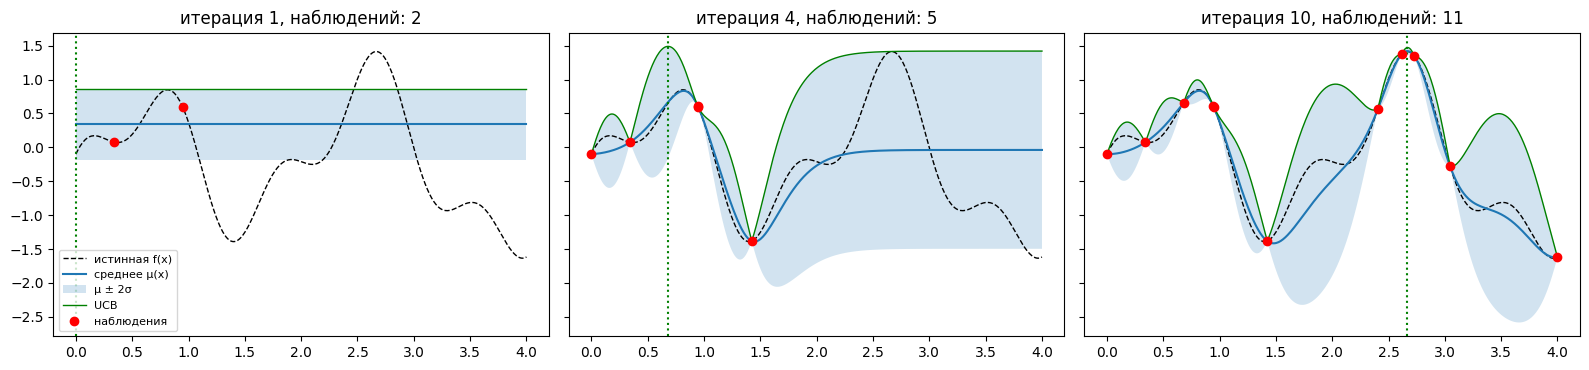

In [26]:
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def f(x): # "дорогая" функция; ищем максимум
    return np.sin(3 * x) + 0.5 * np.cos(7 * x) - 0.15 * (x - 2) ** 2

grid_x = np.linspace(0, 4, 400).reshape(-1, 1)
beta = 4.0
rng = np.random.default_rng(3)
X_obs = rng.uniform(0, 4, size=(2, 1)) # две случайные начальные точки
y_obs = f(X_obs).ravel()

show_at = {0, 3, 9}
fig, axs = plt.subplots(ncols=3, figsize=(16, 3.8), sharey=True)
ax_i = 0
for it in range(10):
    gp = GaussianProcessRegressor(kernel=Matern(length_scale=0.5, nu=2.5), alpha=1e-6,
                                  normalize_y=True, n_restarts_optimizer=3, random_state=0)
    gp.fit(X_obs, y_obs)
    mu, sigma = gp.predict(grid_x, return_std=True)
    ucb = mu + np.sqrt(beta) * sigma
    x_next = grid_x[ucb.argmax()]

    if it in show_at:
        ax = axs[ax_i]; ax_i += 1
        ax.plot(grid_x, f(grid_x), "k--", lw=1, label="истинная f(x)")
        ax.plot(grid_x, mu, label="среднее μ(x)")
        ax.fill_between(grid_x.ravel(), mu - 2 * sigma, mu + 2 * sigma, alpha=0.2, label="μ ± 2σ")
        ax.plot(grid_x, ucb, color="green", lw=1, label="UCB")
        ax.scatter(X_obs, y_obs, c="red", zorder=5, label="наблюдения")
        ax.axvline(x_next, color="green", ls=":")
        ax.set_title(f"итерация {it + 1}, наблюдений: {len(X_obs)}")
        if ax_i == 1: ax.legend(fontsize=8, loc="lower left")

    X_obs = np.vstack([X_obs, x_next.reshape(1, 1)])
    y_obs = np.append(y_obs, f(x_next))

plt.tight_layout()
print(f"Найденный максимум: {y_obs.max():.3f} (истинный: {f(grid_x).max():.3f}), потрачено вычислений f: {len(y_obs)}")

/home/dmitry/any/study/ISP/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'optuna.samplers._tpe.sampler.TPESampler'>


Best trial: 18. Best value: 76.7052: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:12<00:00,  1.57it/s]

Лучший MAE (Optuna, 20 итераций): 76.71
Лучшие параметры: {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 2}



/tmp/ipykernel_584797/1287398058.py:30: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

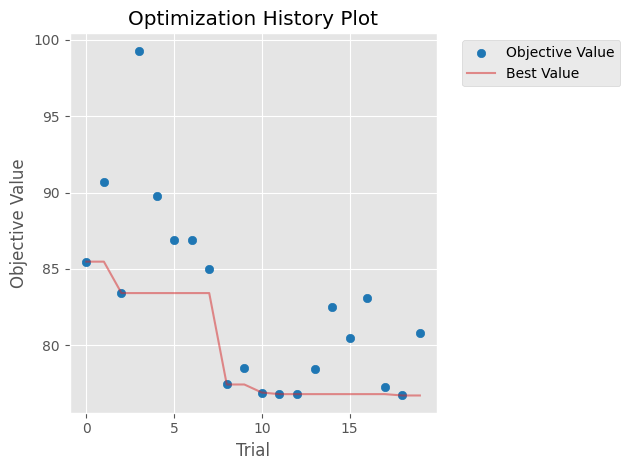

In [27]:
import optuna
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

# те же данные, что и в примере с GridSearchCV
X, y = make_regression(n_samples=300, n_features=10, noise=15, random_state=42)

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 8)

    model = RandomForestRegressor(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf, random_state=42
    )
    score = cross_val_score(model, X, y, cv=3, scoring="neg_mean_absolute_error").mean()
    return -score  # optuna минимизирует

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
print(study.sampler.__class__)  # TPESampler - байесовский по умолчанию
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"Лучший MAE (Optuna, 20 итераций): {study.best_value:.2f}")
print(f"Лучшие параметры: {study.best_params}")

optuna.visualization.matplotlib.plot_optimization_history(study)

#### Optuna: какие гиперпараметры важны?

Помимо `plot_optimization_history`, Optuna умеет оценивать **важность** гиперпараметров (насколько сильно результат зависит от каждого) и показывать «срезы» — как целевая метрика зависит от одного параметра. Это подсказывает, какие параметры стоит искать тщательнее, а какие — зафиксировать и сузить пространство.

array([<Axes: xlabel='max_depth', ylabel='Objective Value'>,
       <Axes: xlabel='min_samples_leaf'>, <Axes: xlabel='n_estimators'>],
      dtype=object)

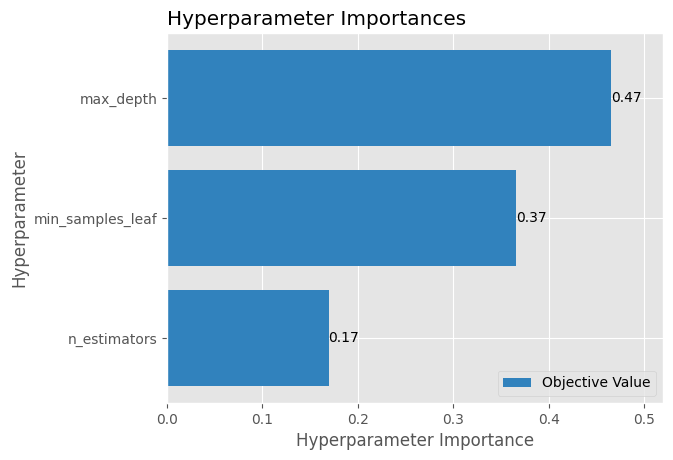

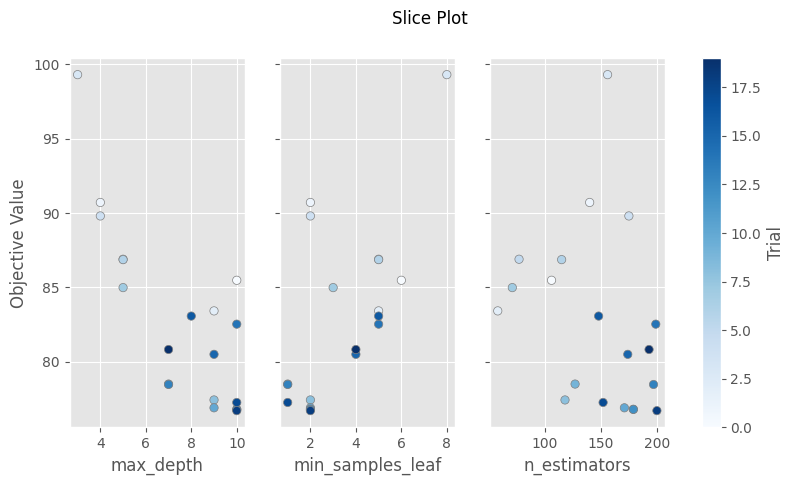

In [28]:
import warnings
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)

optuna.visualization.matplotlib.plot_param_importances(study)
optuna.visualization.matplotlib.plot_slice(study)

#### Сэмплеры: TPE

По умолчанию Optuna использует **TPE** (Tree-structured Parzen Estimator). Важное уточнение к формуле UCB выше: TPE — **не** гауссовский процесс. Вместо моделирования $f(x)$ он делит уже проведённые запуски на «хорошие» и «плохие» и строит две плотности: $\ell(x)$ для хороших и $g(x)$ для плохих; следующая точка выбирается там, где максимально отношение $\ell(x)/g(x)$. Концептуально это тот же баланс exploration/exploitation, но метод хорошо работает с категориальными и условными параметрами и масштабируется на десятки параметров. Классический GP-подход с UCB/EI реализован в `scikit-optimize`, BoTorch;

### Эвристические алгоритмы.

Эвристика - алгоритм решения задачи, включающий практический метод, не являющийся гарантированно точным или оптимальным, но достаточный для решения поставленной задачи.

- Эвристический алгоритм, в отличие от точного, обладает следующими характерными особенностями:
  - При использовании алгоритма результат не всегда будет гарантированно точным;
  - В некоторых случаях алгоритм может привести к неверному результату;
  - Возможен «пропуск цели», то есть решение не будет найдено, даже если известно, что оно заведомо существует;
  - В ряде случаев может быть даже доказано, что эвристический алгоритм формально неверен. Но, несмотря на это, приемлем, если он дает неверный результат только в отдельных случаях, или же дает не абсолютно точный, но все же приемлемый результат.


Примеры: 
- [Генетический алгоритм](https://ru.wikipedia.org/wiki/%D0%93%D0%B5%D0%BD%D0%B5%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B9_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC)
- [Эволюционная стратегия](https://ru.wikipedia.org/wiki/%D0%AD%D0%B2%D0%BE%D0%BB%D1%8E%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D0%B0%D1%8F_%D1%81%D1%82%D1%80%D0%B0%D1%82%D0%B5%D0%B3%D0%B8%D1%8F)
- [Дифференциальная эволюция](https://ru.wikipedia.org/wiki/%D0%94%D0%B8%D1%84%D1%84%D0%B5%D1%80%D0%B5%D0%BD%D1%86%D0%B8%D0%B0%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_%D1%8D%D0%B2%D0%BE%D0%BB%D1%8E%D1%86%D0%B8%D1%8F)

#### Эвристики на практике: генетический алгоритм для гиперпараметров

Как эвристики применяются именно к подбору гиперпараметров: **особь** = набор гиперпараметров, **приспособленность** = качество по кросс-валидации, дальше цикл: отбор → скрещивание → мутация → новое поколение. Ниже — минимальная реализация на тех же данных и той же модели, что в примере с `GridSearchCV`; для честности сравним с случайным поиском при **таком же числе вычислений** целевой функции.

In [29]:
import random

X_ga, y_ga = make_regression(n_samples=300, n_features=10, noise=15, random_state=42)
SPACE = {"n_estimators": (50, 200), "max_depth": (3, 10), "min_samples_leaf": (1, 8)}
cache = {}

def fitness(g):                                    # MAE по кросс-валидации, минимизируем
    key = tuple(g[k] for k in SPACE)
    if key not in cache:                           # не пересчитываем одинаковые особи
        model = RandomForestRegressor(**g, random_state=42, n_jobs=-1)
        cache[key] = -cross_val_score(model, X_ga, y_ga, cv=3, scoring="neg_mean_absolute_error").mean()
    return cache[key]

def random_genome():
    return {k: random.randint(lo, hi) for k, (lo, hi) in SPACE.items()}

def crossover(a, b):                               # каждый ген — от случайного родителя
    return {k: random.choice([a[k], b[k]]) for k in SPACE}

def mutate(g, p=0.3):                              # с вероятностью p ген заменяется на случайное значение
    return {k: (random.randint(*SPACE[k]) if random.random() < p else v) for k, v in g.items()}

def tournament(pop, k=3):                          # лучший из k случайных
    return min(random.sample(pop, k), key=fitness)

random.seed(0)
POP, GENS, ELITE = 8, 6, 2
population = [random_genome() for _ in range(POP)]
for gen in range(GENS):
    population.sort(key=fitness)
    print(f"поколение {gen}: лучший MAE = {fitness(population[0]):.2f}, вычислений: {len(cache)}")
    children = population[:ELITE]                  # элитизм: лучшие переходят без изменений
    while len(children) < POP:
        children.append(mutate(crossover(tournament(population), tournament(population))))
    population = children

best = min(population, key=fitness)
budget = len(cache)
print(f"\nГА:              MAE = {fitness(best):.2f} за {budget} вычислений, {best}")

random.seed(1)                                     # baseline: случайный поиск с тем же бюджетом
rand_best = min((random_genome() for _ in range(budget)), key=fitness)
print(f"Случайный поиск: MAE = {fitness(rand_best):.2f} за {budget} вычислений, {rand_best}")

поколение 0: лучший MAE = 77.45, вычислений: 8
поколение 1: лучший MAE = 77.45, вычислений: 14
поколение 2: лучший MAE = 77.30, вычислений: 20
поколение 3: лучший MAE = 77.30, вычислений: 23
поколение 4: лучший MAE = 77.30, вычислений: 26
поколение 5: лучший MAE = 77.20, вычислений: 32

ГА:              MAE = 77.20 за 35 вычислений, {'n_estimators': 174, 'max_depth': 9, 'min_samples_leaf': 1}
Случайный поиск: MAE = 77.11 за 35 вычислений, {'n_estimators': 190, 'max_depth': 8, 'min_samples_leaf': 2}


Для **непрерывных** гиперпараметров есть готовая эвристика в `scipy` — **дифференциальная эволюция** (`scipy.optimize.differential_evolution`). Ей нужна функция потерь и границы; масштаб параметров вроде `C` и `gamma` удобно искать в log-пространстве.

In [30]:
from scipy.optimize import differential_evolution
from sklearn.svm import SVR

def loss(p):                                       # p = [log10(C), log10(gamma)]
    model = SVR(C=10 ** p[0], gamma=10 ** p[1])
    return -cross_val_score(model, X_ga, y_ga, cv=3, scoring="neg_mean_absolute_error").mean()

default_mae = -cross_val_score(SVR(), X_ga, y_ga, cv=3, scoring="neg_mean_absolute_error").mean()
res = differential_evolution(loss, bounds=[(-2, 3), (-4, 0)], popsize=8, maxiter=10,
                             seed=0, polish=False)
print(f"SVR с параметрами по умолчанию:  MAE = {default_mae:.2f}")
print(f"Дифференциальная эволюция:       MAE = {res.fun:.2f}  "
      f"(C = {10 ** res.x[0]:.2f}, gamma = {10 ** res.x[1]:.4f}), вычислений: {res.nfev}")

SVR с параметрами по умолчанию:  MAE = 143.34
Дифференциальная эволюция:       MAE = 14.14  (C = 968.65, gamma = 0.0038), вычислений: 176


Обратите внимание на результат сравнения с ГА выше: на таком маленьком и почти «плоском» пространстве (три параметра, качество слабо зависит от каждого) генетический алгоритм не обязан обыгрывать случайный поиск — в пробном прогоне значения практически совпали. Это нормально и тоже полезный урок: эвристика — не серебряная пуля, а инструмент под определённый тип задач.

**Когда эвристики оправданы:** нечёткое, дискретное или «условное» пространство (архитектура сети, структура пайплайна), недифференцируемая и зашумлённая целевая функция, дешёвые вычисления и возможность параллелить всё поколение. **Когда нет:** мало бюджета и гладкое пространство — там байесовская оптимизация обычно эффективнее. У Optuna, кстати, есть и эволюционные сэмплеры (`NSGAIISampler`, `CmaEsSampler`) — то есть эвристики и фреймворк подбора не противопоставляются.

## Шпаргалка: что и когда использовать

**Схема разбиения**

| Ситуация | Что использовать |
|---|---|
| Много данных, обучение дорогое | один отложенный train / validation / test |
| Данных немного или умеренно | K-Fold (K = 5–10), при необходимости `RepeatedKFold` |
| Несбалансированные классы | `stratify=` в `train_test_split`, `StratifiedKFold` |
| Очень мало данных (десятки–сотни объектов) | LOO, бутстреп (OOB) |
| Данные упорядочены во времени | `TimeSeriesSplit`, **никакого** shuffle |
| Несколько объектов от одного пациента / пользователя / документа | групповые схемы (`GroupKFold`) — в ноутбуке не разбирали, см. документацию sklearn |

**Метод подбора гиперпараметров**

| Метод | Когда |
|---|---|
| `GridSearchCV` | 1–3 параметра, небольшая сетка |
| `RandomizedSearchCV` | больше параметров, часть из них почти не важна |
| `HalvingGridSearchCV` / `HalvingRandomSearchCV` | много кандидатов, много данных, дорогая модель |
| Optuna (TPE) + pruning | дорогая целевая функция, итеративное обучение, условные параметры |
| Эволюционные методы | сложное дискретное пространство, шумная целевая функция |

**Итоговый порядок работы**

1. Сразу отложить **test** и не трогать до конца.
2. Собрать `Pipeline` (препроцессинг + модель) — никаких `fit` на всех данных до CV.
3. Выбрать схему разбиения под природу данных (время, группы, дисбаланс).
4. Посмотреть `learning_curve` / `validation_curve`: переобучение или недообучение?
5. Подобрать гиперпараметры на train через CV (Random / Halving / Optuna).
6. При малом числе данных оценить *процедуру* через nested CV.
7. Дообучить лучшую модель на всём train и **один раз** оценить на test.

## Ссылки.

- [Кросс-валидация handbook](https://education.yandex.ru/handbook/ml/article/kross-validaciya)
- [Кросс-валидация nerc](https://neerc.ifmo.ru/wiki/index.php?title=%D0%9A%D1%80%D0%BE%D1%81%D1%81-%D0%B2%D0%B0%D0%BB%D0%B8%D0%B4%D0%B0%D1%86%D0%B8%D1%8F)
- [Лекция: Контроль качества и выбор модели. Дьяконов А.Г.](https://github.com/Dyakonov/MSUML/blob/main/2021autumn/ML040_control_202110a_______.pdf)
- [Видео лекции: Контроль качества и выбор модели. Дьяконов А.Г.](https://www.youtube.com/watch?v=Q2jJ8_oU3-s&list=PLhe7c-LCgl4Ic-FRawaaEhUmDCQmGMtzx&index=7)
- [Cross-Validation in Machine Learning: How to Do It Right](https://neptune.ai/blog/cross-validation-in-machine-learning-how-to-do-it-right)
- [Подбор гиперпараметров](https://education.yandex.ru/handbook/ml/article/podbor-giperparametrov)
- [Optuna: подбор гиперпараметров для вашей модели](https://practicum.yandex.ru/blog/optuna-podbor-giperparametrov/)
- [HyperBand и BOHB. Понимание современных алгоритмов оптимизации гиперпараметров](https://habr.com/ru/companies/skillfactory/articles/528240/)
- [Hyperparameter optimization for Neural Networks](http://neupy.com/2016/12/17/hyperparameter_optimization_for_neural_networks.html)
- [scikit-learn: Common pitfalls (утечки данных, Pipeline)](https://scikit-learn.org/stable/common_pitfalls.html)
- [scikit-learn: Learning curves и validation curves](https://scikit-learn.org/stable/modules/learning_curve.html)
- [scikit-learn: Successive halving](https://scikit-learn.org/stable/modules/grid_search.html#successive-halving-user-guide)
- [scikit-learn: пример Nested vs Non-nested CV](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html)
- [Optuna: документация (samplers, pruners, visualization)](https://optuna.readthedocs.io/)